<a href="https://colab.research.google.com/github/harshitschooled/AI-ML-Internship/blob/main/Day_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

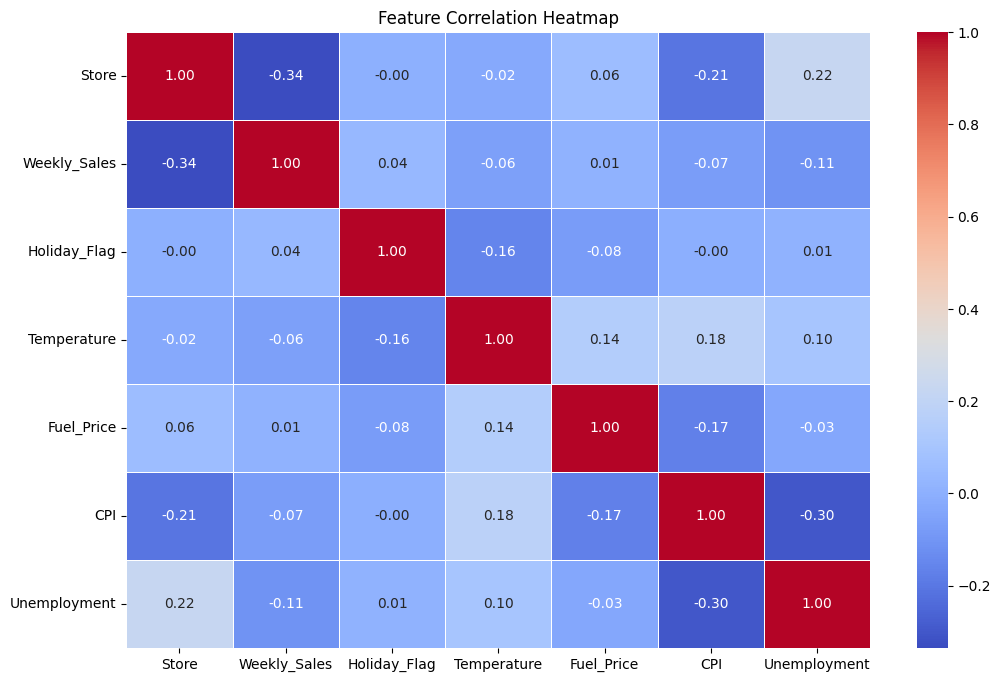

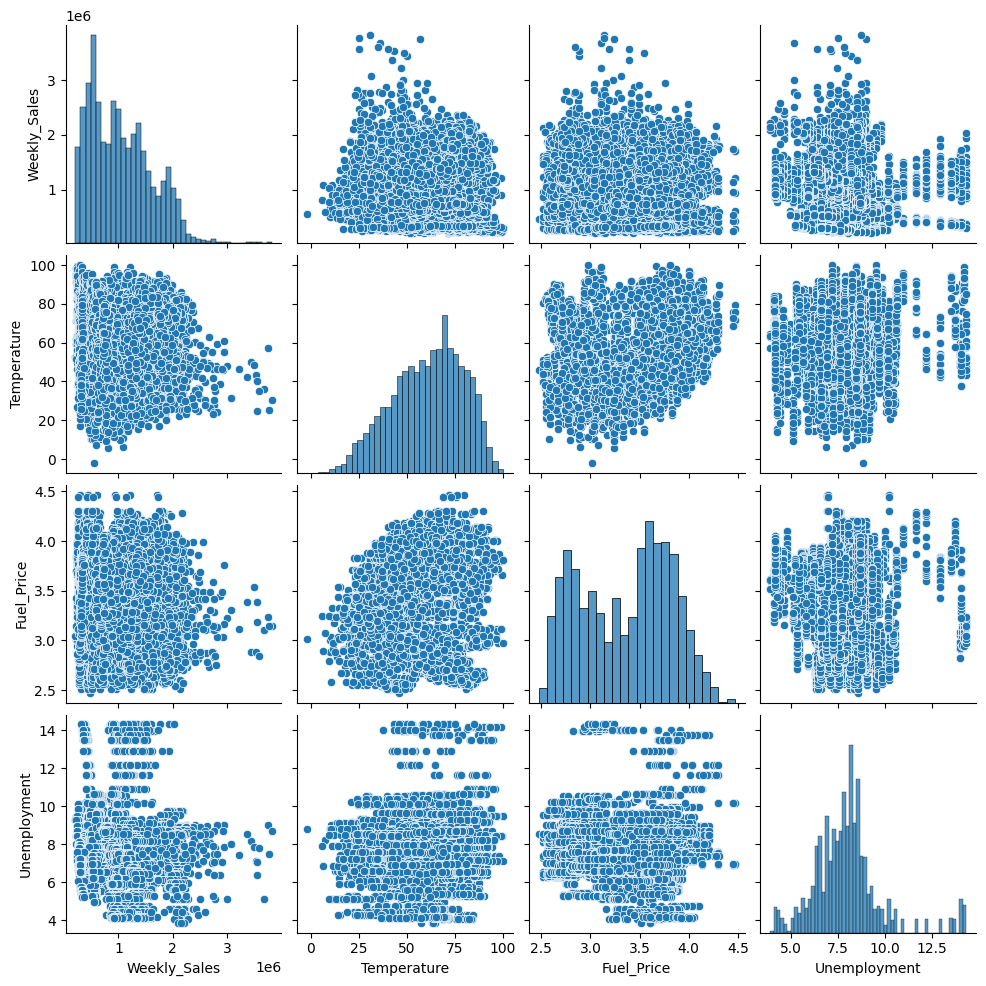

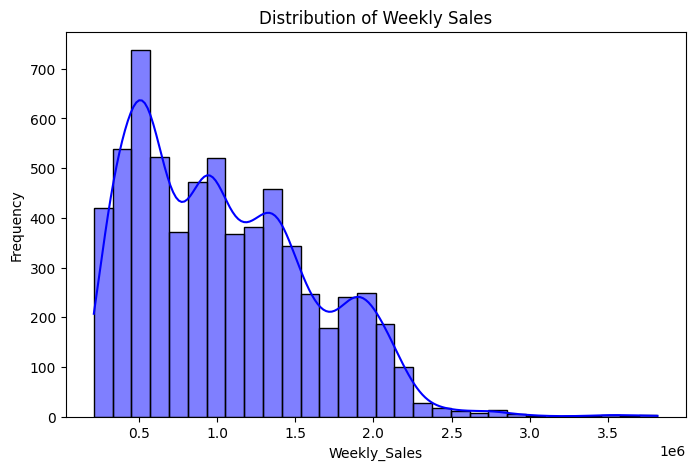

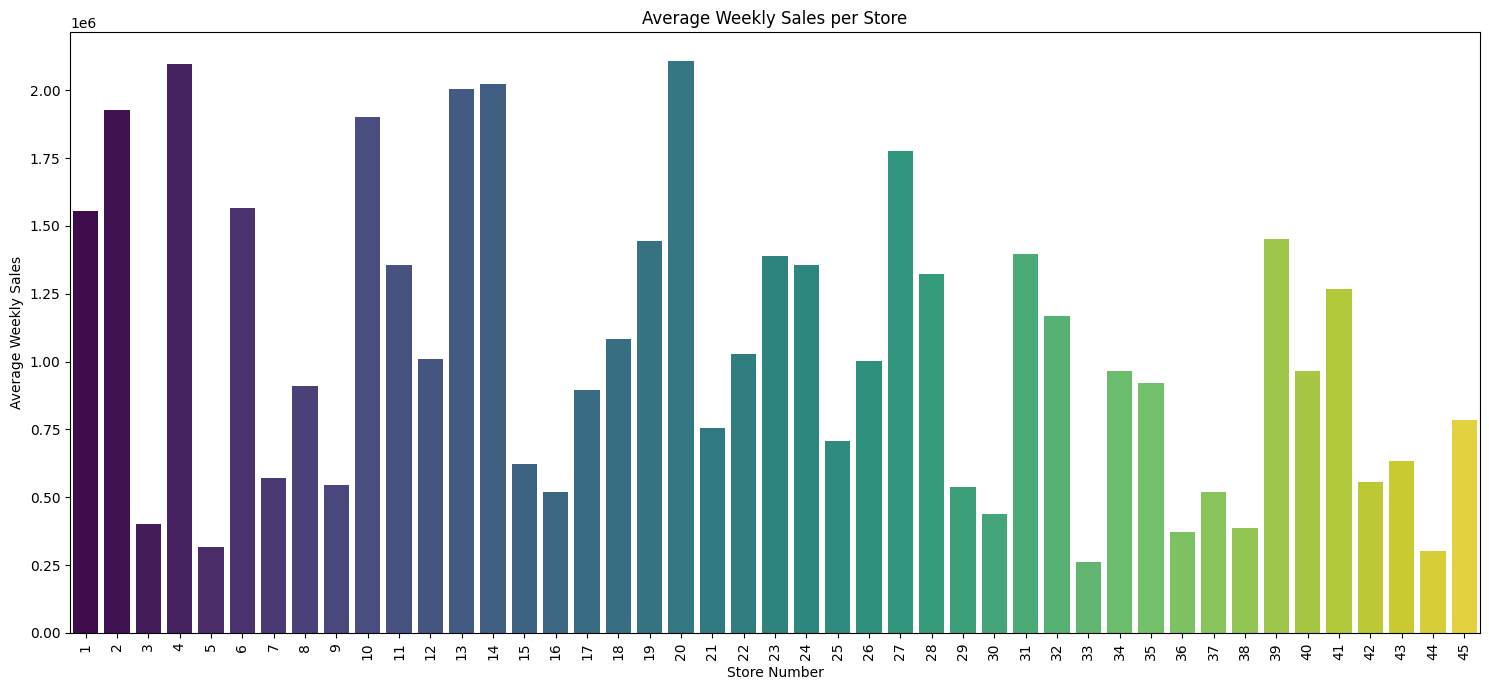

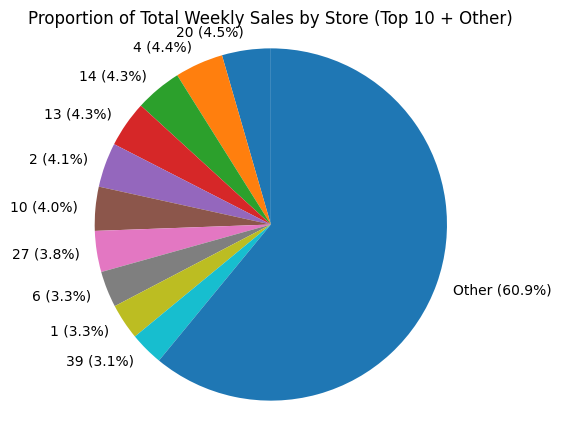

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'Unemployment']])
plt.show()

# Distribution of target variable (Weekly_SAles)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()

weekly_sales_by_store = df.groupby('Store')['Weekly_Sales'].mean().reset_index()
weekly_sales_by_store = weekly_sales_by_store.sort_values(by='Weekly_Sales', ascending=False)

plt.figure(figsize=(15, 7))
sns.barplot(x='Store', y='Weekly_Sales', data=weekly_sales_by_store, palette='viridis', hue='Store', legend=False)
plt.title('Average Weekly Sales per Store')
plt.xlabel('Store Number')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

# Calculate the total weekly sales across all stores
total_sales = weekly_sales_by_store['Weekly_Sales'].sum()

# Get top 10 stores by average weekly sales
top_10_stores = weekly_sales_by_store.head(10)

# Calculate sales for 'Other' stores
other_sales = total_sales - top_10_stores['Weekly_Sales'].sum()

# Create a new DataFrame for the pie chart, including 'Other'
pie_chart_data = top_10_stores.copy()
pie_chart_data.loc['Other'] = {'Store': 'Other', 'Weekly_Sales': other_sales}

# Prepare data for pie chart
labels = pie_chart_data['Store'].astype(str) + ' (' + (pie_chart_data['Weekly_Sales'] / total_sales * 100).round(1).astype(str) + '%)'
sizes = pie_chart_data['Weekly_Sales']

# Create the pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='', startangle=90, pctdistance=0.85)
plt.title('Proportion of Total Weekly Sales by Store (Top 10 + Other)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Define features (X) and target (y)
y = df['Weekly_Sales']

# Select features for the model.
X = df[['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.0174
RMSE: 562631.7725


In [88]:
df = df.drop('Date', axis=1)
print("DataFrame columns after dropping 'Date' column:")
print(df.columns)

DataFrame columns after dropping 'Date' column:
Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='object')


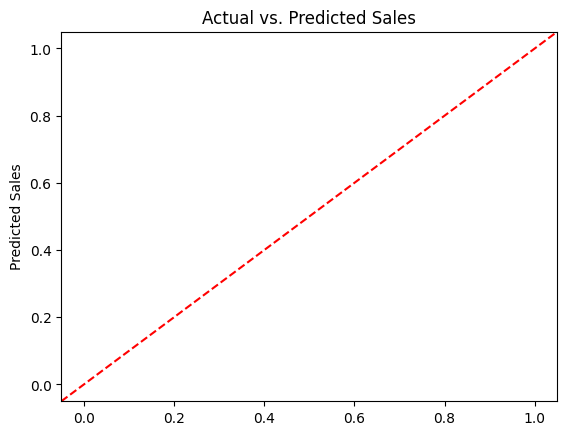

In [89]:

plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

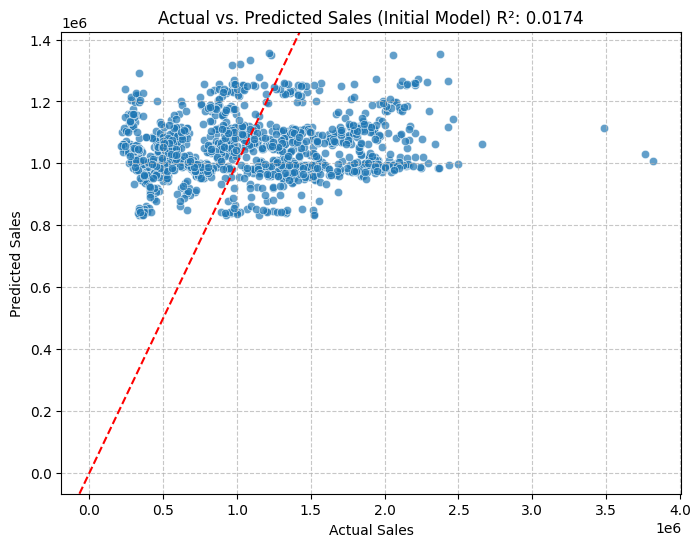

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Assuming y_test, y_pred, and r2 are available from the initial linear regression model

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs. Predicted Sales (Initial Model) R²: {r2:.4f}")
plt.axline([0, 0], [1, 1], color="red", linestyle="--") # Add a diagonal line for ideal prediction
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

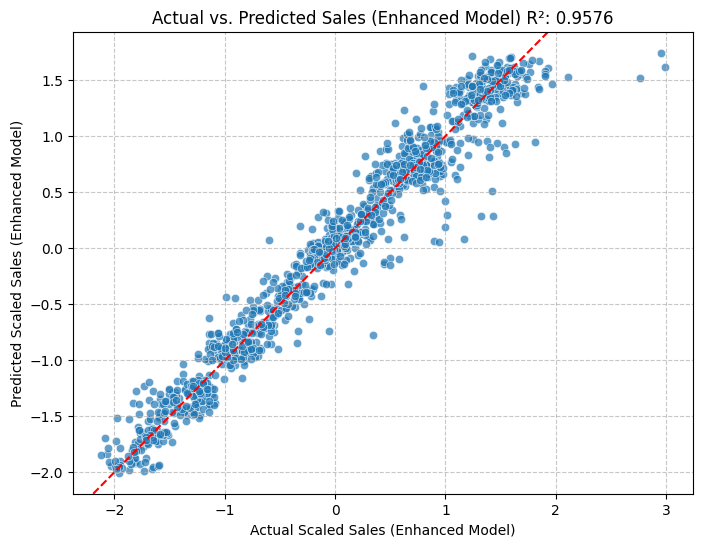

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

# --- Re-execute Feature Engineering for Enhanced Model (to ensure variable availability) ---
# This section is included to ensure all necessary variables for plotting the enhanced model are defined.
# In a typical notebook workflow, these steps would have been executed in prior cells.

# Load the original dataset
df_enhanced = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Extract temporal features
df_enhanced['Date'] = pd.to_datetime(df_enhanced['Date'], format='%d-%m-%Y')
df_enhanced['Year'] = df_enhanced['Date'].dt.year
df_enhanced['Month'] = df_enhanced['Date'].dt.month
df_enhanced['Day'] = df_enhanced['Date'].dt.day
df_enhanced['WeekOfYear'] = df_enhanced['Date'].dt.isocalendar().week.astype(int)
df_enhanced['DayOfWeek'] = df_enhanced['Date'].dt.dayofweek # Monday=0, Sunday=6
df_enhanced = df_enhanced.drop('Date', axis=1)

# One-Hot Encode 'Store' and 'DayOfWeek'
df_enhanced = pd.get_dummies(df_enhanced, columns=['Store', 'DayOfWeek'], drop_first=True)

# Separate target variable before scaling
y_enhanced = df_enhanced['Weekly_Sales']
X_enhanced = df_enhanced.drop('Weekly_Sales', axis=1)

# Identify numerical columns for Power Transformation
continuous_numerical_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'WeekOfYear']

# Apply PowerTransformer to numerical features and target variable
pt_features = PowerTransformer(method='yeo-johnson')
X_enhanced_scaled = pt_features.fit_transform(X_enhanced[continuous_numerical_cols])
X_enhanced_scaled_df = pd.DataFrame(X_enhanced_scaled, columns=continuous_numerical_cols, index=X_enhanced.index)

# Combine scaled numerical features with one-hot encoded features
X_enhanced_processed = pd.concat([X_enhanced_scaled_df, X_enhanced.drop(columns=continuous_numerical_cols)], axis=1)

pt_target = PowerTransformer(method='yeo-johnson')
y_enhanced_scaled = pt_target.fit_transform(y_enhanced.values.reshape(-1, 1)).flatten()

# Split the enhanced dataset
X_train_enhanced_scaled, X_test_enhanced_scaled, y_train_enhanced_scaled, y_test_enhanced_scaled = train_test_split(X_enhanced_processed, y_enhanced_scaled, test_size=0.2, random_state=42)

# Train Linear Regression Model on enhanced scaled data
model_enhanced = LinearRegression()
model_enhanced.fit(X_train_enhanced_scaled, y_train_enhanced_scaled)

# Predictions for enhanced model
y_pred_enhanced_scaled = model_enhanced.predict(X_test_enhanced_scaled)

# Model Evaluation for enhanced model
r2_enhanced = r2_score(y_test_enhanced_scaled, y_pred_enhanced_scaled)

# --- Plotting Enhanced Model Scatter Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_enhanced_scaled, y=y_pred_enhanced_scaled, alpha=0.7)
plt.xlabel("Actual Scaled Sales (Enhanced Model)")
plt.ylabel("Predicted Scaled Sales (Enhanced Model)")
plt.title(f"Actual vs. Predicted Sales (Enhanced Model) R²: {r2_enhanced:.4f}")
plt.axline([0, 0], [1, 1], color="red", linestyle="--") # Add a diagonal line for ideal prediction
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [92]:
num_cols = len(df.columns)
plt.figure(figsize=(15, num_cols * 5))

<Figure size 1500x3500 with 0 Axes>

<Figure size 1500x3500 with 0 Axes>

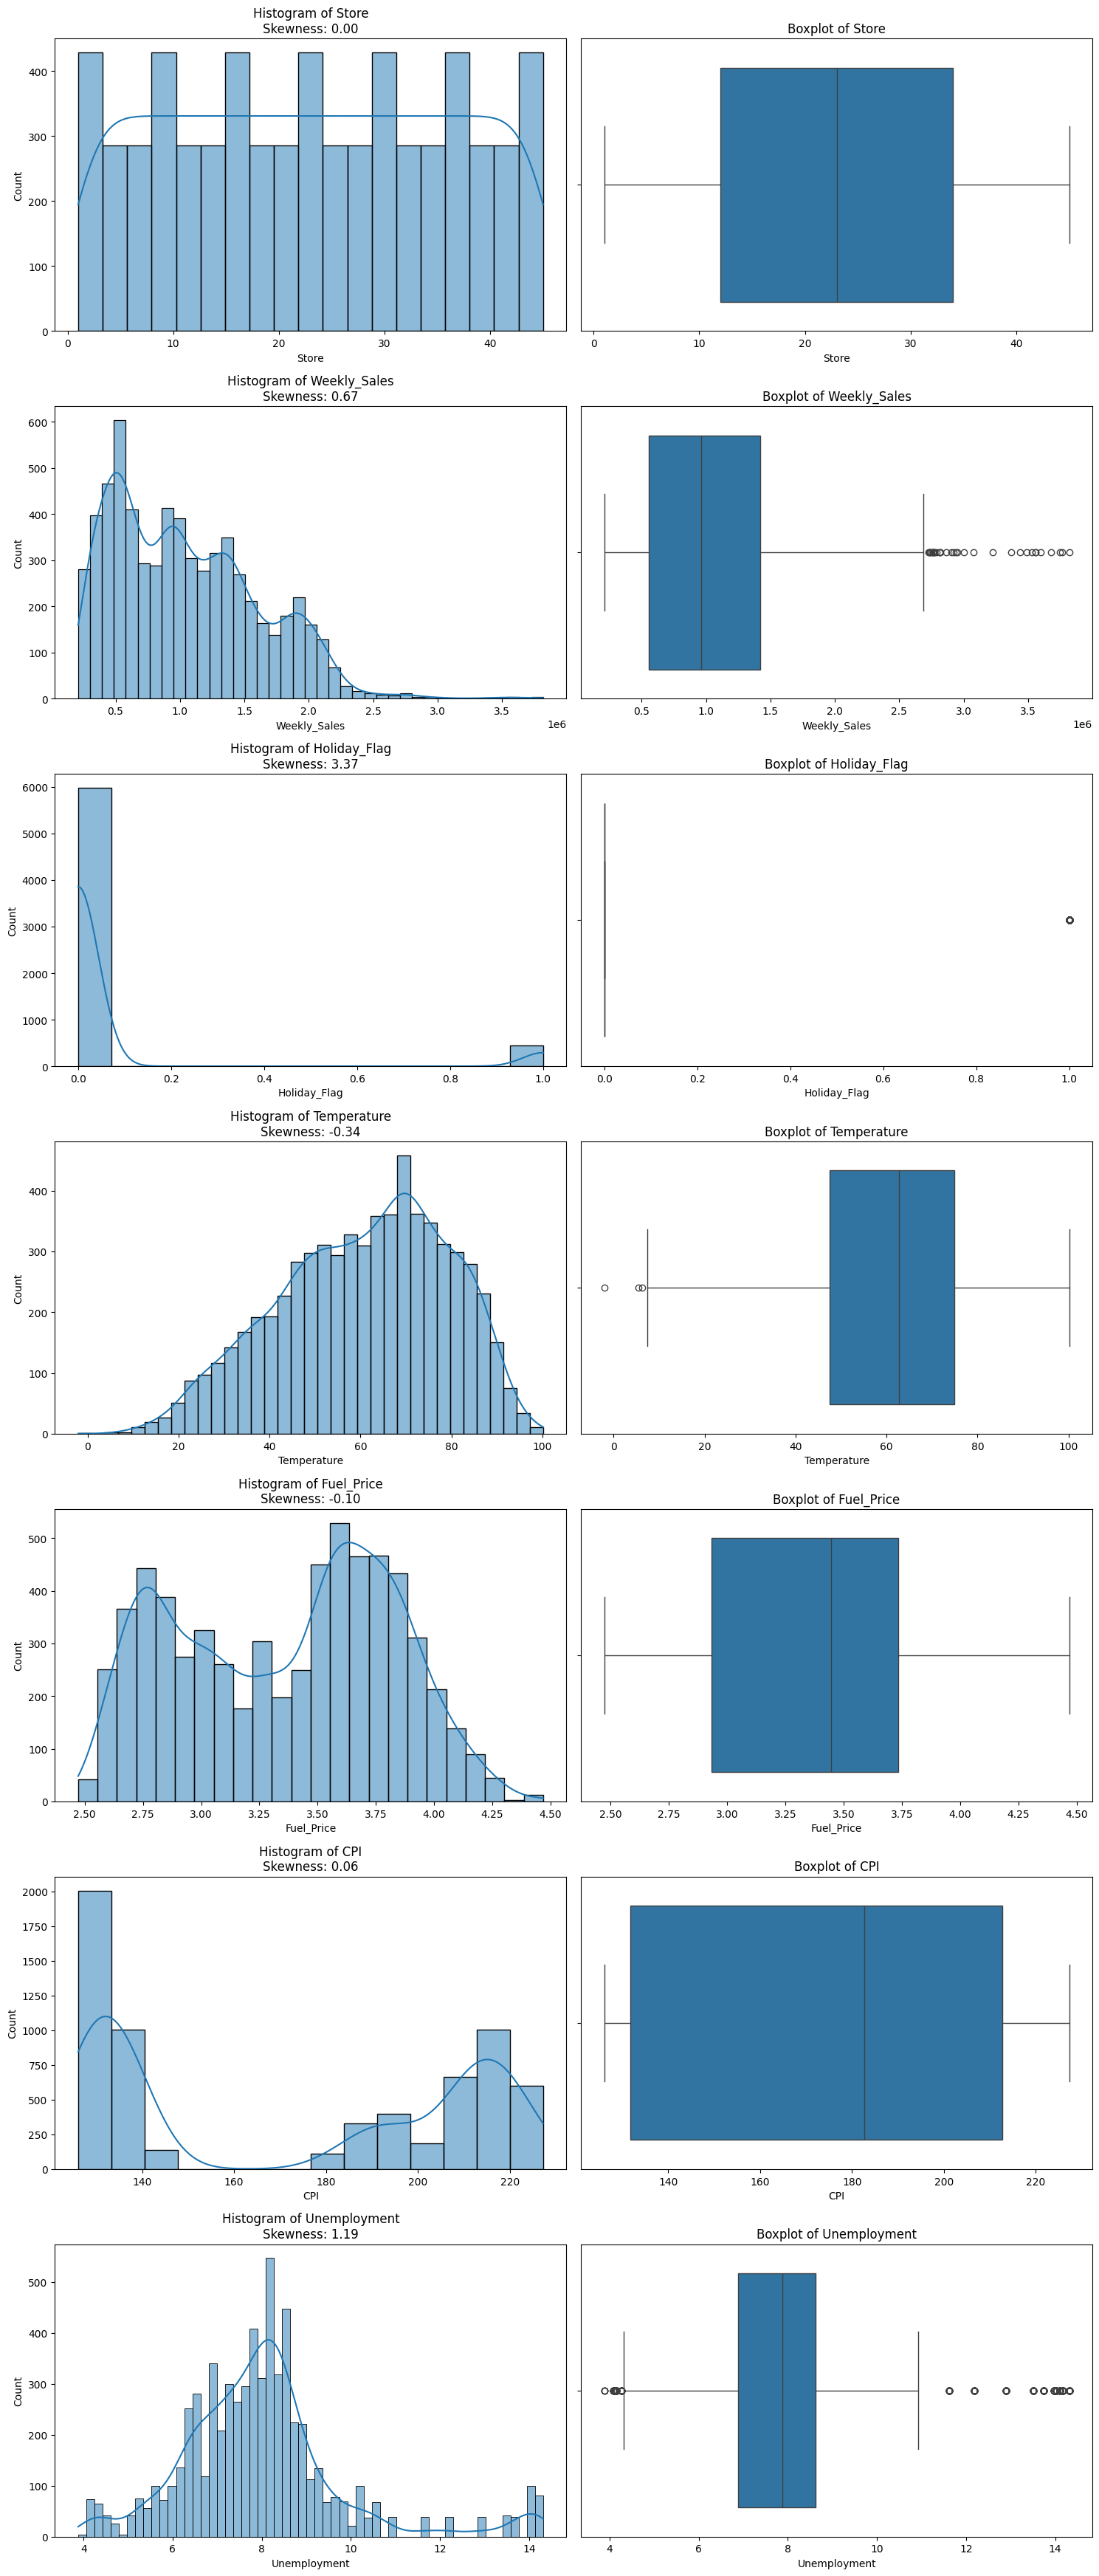

In [93]:
numeric_df = df.select_dtypes(include=['number'])
skewness = numeric_df.skew()

numeric_cols = numeric_df.columns
num_cols_to_plot = len(numeric_cols)
num_rows = num_cols_to_plot # Each column gets one row with a hist and a boxplot

# Create figure and a grid of subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(15, num_rows * 5))

# Iterate through each numeric column to plot its distribution
for i, col in enumerate(numeric_cols):
    # Histogram for the current column
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')
    axes[i, 0].set_xlabel(col) #
    # Boxplot for the current column
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col) # Set x-label to column name for clarity

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plots

In [94]:
df.select_dtypes(include=['number']).skew()

,0
Store,0.000000
Weekly_Sales,0.668362
Holiday_Flag,3.373499
Temperature,-0.336768
Fuel_Price,-0.096158
CPI,0.063492
Unemployment,1.188144


In [95]:
import numpy as np
skewed_cols = df.select_dtypes(include=['number']).skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index
print("Negatively skewed columns:\n",negatively_skewed)
print("Highly Skewed Columns:\n",highly_skewed)

Negatively skewed columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')
Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')


In [96]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method='yeo-johnson')
# Extracting additional temporal features: Beyond Year, Month, Day, we'll add WeekOfYear and DayOfWeek from
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [97]:
df[highly_skewed]

,Holiday_Flag,Unemployment
0,0,8.106
1,1,8.106
2,0,8.106
3,0,8.106
4,0,8.106
...,...,...
6430,0,8.684
6431,0,8.667
6432,0,8.667
6433,0,8.667


In [98]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 'Date' column was dropped in a previous step (dd16e352).
# 'Year', 'Month', 'Day' were extracted into 'df_enhanced', not 'df'.
# So, this cell will use features that are available in 'df' at this point.

# Define features (X) and target (y)
y = df['Weekly_Sales']

# Select features that are available in 'df' after 'Date' has been dropped
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1273
RMSE: 0.9462


In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PowerTransformer
import numpy as np

# --- Step 1: Reload the original dataset and extract temporal features ---
print("Reloading original dataset and extracting temporal features...")
df_enhanced = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")
df_enhanced['Date'] = pd.to_datetime(df_enhanced['Date'], format='%d-%m-%Y')

df_enhanced['Year'] = df_enhanced['Date'].dt.year
df_enhanced['Month'] = df_enhanced['Date'].dt.month
df_enhanced['Day'] = df_enhanced['Date'].dt.day
df_enhanced['WeekOfYear'] = df_enhanced['Date'].dt.isocalendar().week.astype(int)
df_enhanced['DayOfWeek'] = df_enhanced['Date'].dt.dayofweek # Monday=0, Sunday=6

# Drop the original 'Date' column as its components are now extracted
df_enhanced = df_enhanced.drop('Date', axis=1)
https://colab.research.google.com/drive/10FNFtj_G9v3dzDysGCehE5ZNNQRv1sa6?usp=sharing


print(f"R² Score: {r2:.4f}")

Don't qorr
print("Temporal features extracted. Displaying head of enhanced DataFrame:")
display(df_enhanced.head())

SyntaxError: invalid decimal literal (2671233458.py, line 21)

In [ ]:
# --- Step 2: One-Hot Encode 'Store' and 'DayOfWeek' ---
print("One-hot encoding 'Store' and 'DayOfWeek'...")
df_enhanced = pd.get_dummies(df_enhanced, columns=['Store', 'DayOfWeek'], drop_first=True)

print("One-hot encoding complete. Displaying head and info of DataFrame:")
display(df_enhanced.head())
print(df_enhanced.info())